$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.3

考虑式 (3.5) 中的最大熵准则：

$$
\max_D |\boldsymbol{R}|
\tag{4.13}
$$

设 $\lambda_1,\dots,\lambda_n$ 为矩阵 $\boldsymbol{R}$ 的特征值。根据几何均值恒小于算术均值的性质可得：

$$
\begin{align*}
|\boldsymbol{R}|&=\prod_{i=1}^n \lambda_i \le \left( \frac{1}{n}\sum_{i=1}^n \lambda_i \right)^n\\
&=\left( \frac{1}{n}tr\{\boldsymbol{R}\} \right)^n=1=|\boldsymbol{I}_n|
\end{align*}
$$

其中由于 $\boldsymbol{R}=R(\boldsymbol{x}_{i}-\boldsymbol{x}_{j})$，有 $tr(\boldsymbol{R})=\sum_{i=1}^n R(\boldsymbol{0})=n$。由此可知，最大熵准则的本质是让相关矩阵尽可能逼近单位矩阵，也就是尽可能最小化 $\boldsymbol{R}$ 的非对角元素。据此，式 (4.13) 的替代准则可写为：

$$
\min_D \|\boldsymbol{R}-\boldsymbol{I}_n\|_\alpha
\tag{4.14}
$$

式中 $\|\cdot\|_\alpha$ 代表 $L_\alpha$ 范数。相较于式 (4.13)，式 (4.14) 的优势在于其目标函数的计算复杂度为 $\mathcal{O}(n^2)$，而式 (4.13) 的计算复杂度为 $\mathcal{O}(n^3)$，这为优化计算带来了显著的运算优势。

考虑无穷范数。由于矩阵 $\boldsymbol{R}$ 为正定矩阵（针对绝大多数常用相关函数而言），式 (4.14) 可化为：

$$
\min_{D}\max_{i\neq j}|\boldsymbol{R}_{ij}| = \min_{D}\max_{i\neq j}\boldsymbol{R}_{ij}
\tag{4.15}
$$

若在式 (4.3) 中选用各向同性高斯相关函数，则：

$$
\begin{align*}
\max_{i\neq j}\boldsymbol{R}_{ij}
&= \max_{i\neq j}\exp\left(-\frac{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^2}{\theta^2}\right) \\
&= \exp\left(-\min_{i\neq j}\frac{\|\boldsymbol{x}_i-\boldsymbol{x}_j\|^2}{\theta^2}\right) \\
&= \exp\left(-4\frac{\psi^2(D)}{\theta^2}\right),
\end{align*}
$$

其中

$$
\psi(D) := \frac{1}{2}\min_{i\neq j}\|\boldsymbol{x}_i-\boldsymbol{x}_j\|
$$

被称作设计 $D$ 的分离距离（也叫填充半径）。能够最大化分离距离的设计称为极大极小距离设计，简称极大极小设计，其表达式为：

$$
D^*= \argmax_{D}\min_{i\neq j}\|\boldsymbol{x}_i-\boldsymbol{x}_j\|
\tag{4.16}
$$

由此可知，极大极小设计的目标是最大化所有设计点两两之间的最小距离。该类设计能够最小化矩阵 $\boldsymbol{R}$ 非对角元的最大值，进而近似最大化设计的熵。从几何角度来看，极大极小设计尽可能分散样本点，以期完整填充整个试验区域 $\mathcal{X}$。

极大极小设计并非唯一。图 4.3 展示了两组具有相同分离距离的设计方案，但显然第一种设计更优，原因是该设计中仅有一组点对取到最小距离，而第二种设计存在两组这样的点对。我们将距离为 $2\psi(D)$ 的点对数量定义为该设计的（极大极小）指标。我们希望这一指标尽可能小，避免过多点位相互靠近。因此，可以将设计指标作为次级准则，对极大极小设计进行优化筛选。我们有下述结论。

> **定理 4.2** 设相关函数 $R(\boldsymbol{u}, \boldsymbol{v}) = \rho k(d(\boldsymbol{u}, \boldsymbol{v}))$，其中 $d$ 为距离度量，$\rho$ 为递减函数，且 $k>0$。则当 $k \to \infty$ 时，最低指标的极大极小设计渐近等价于最大熵设计。

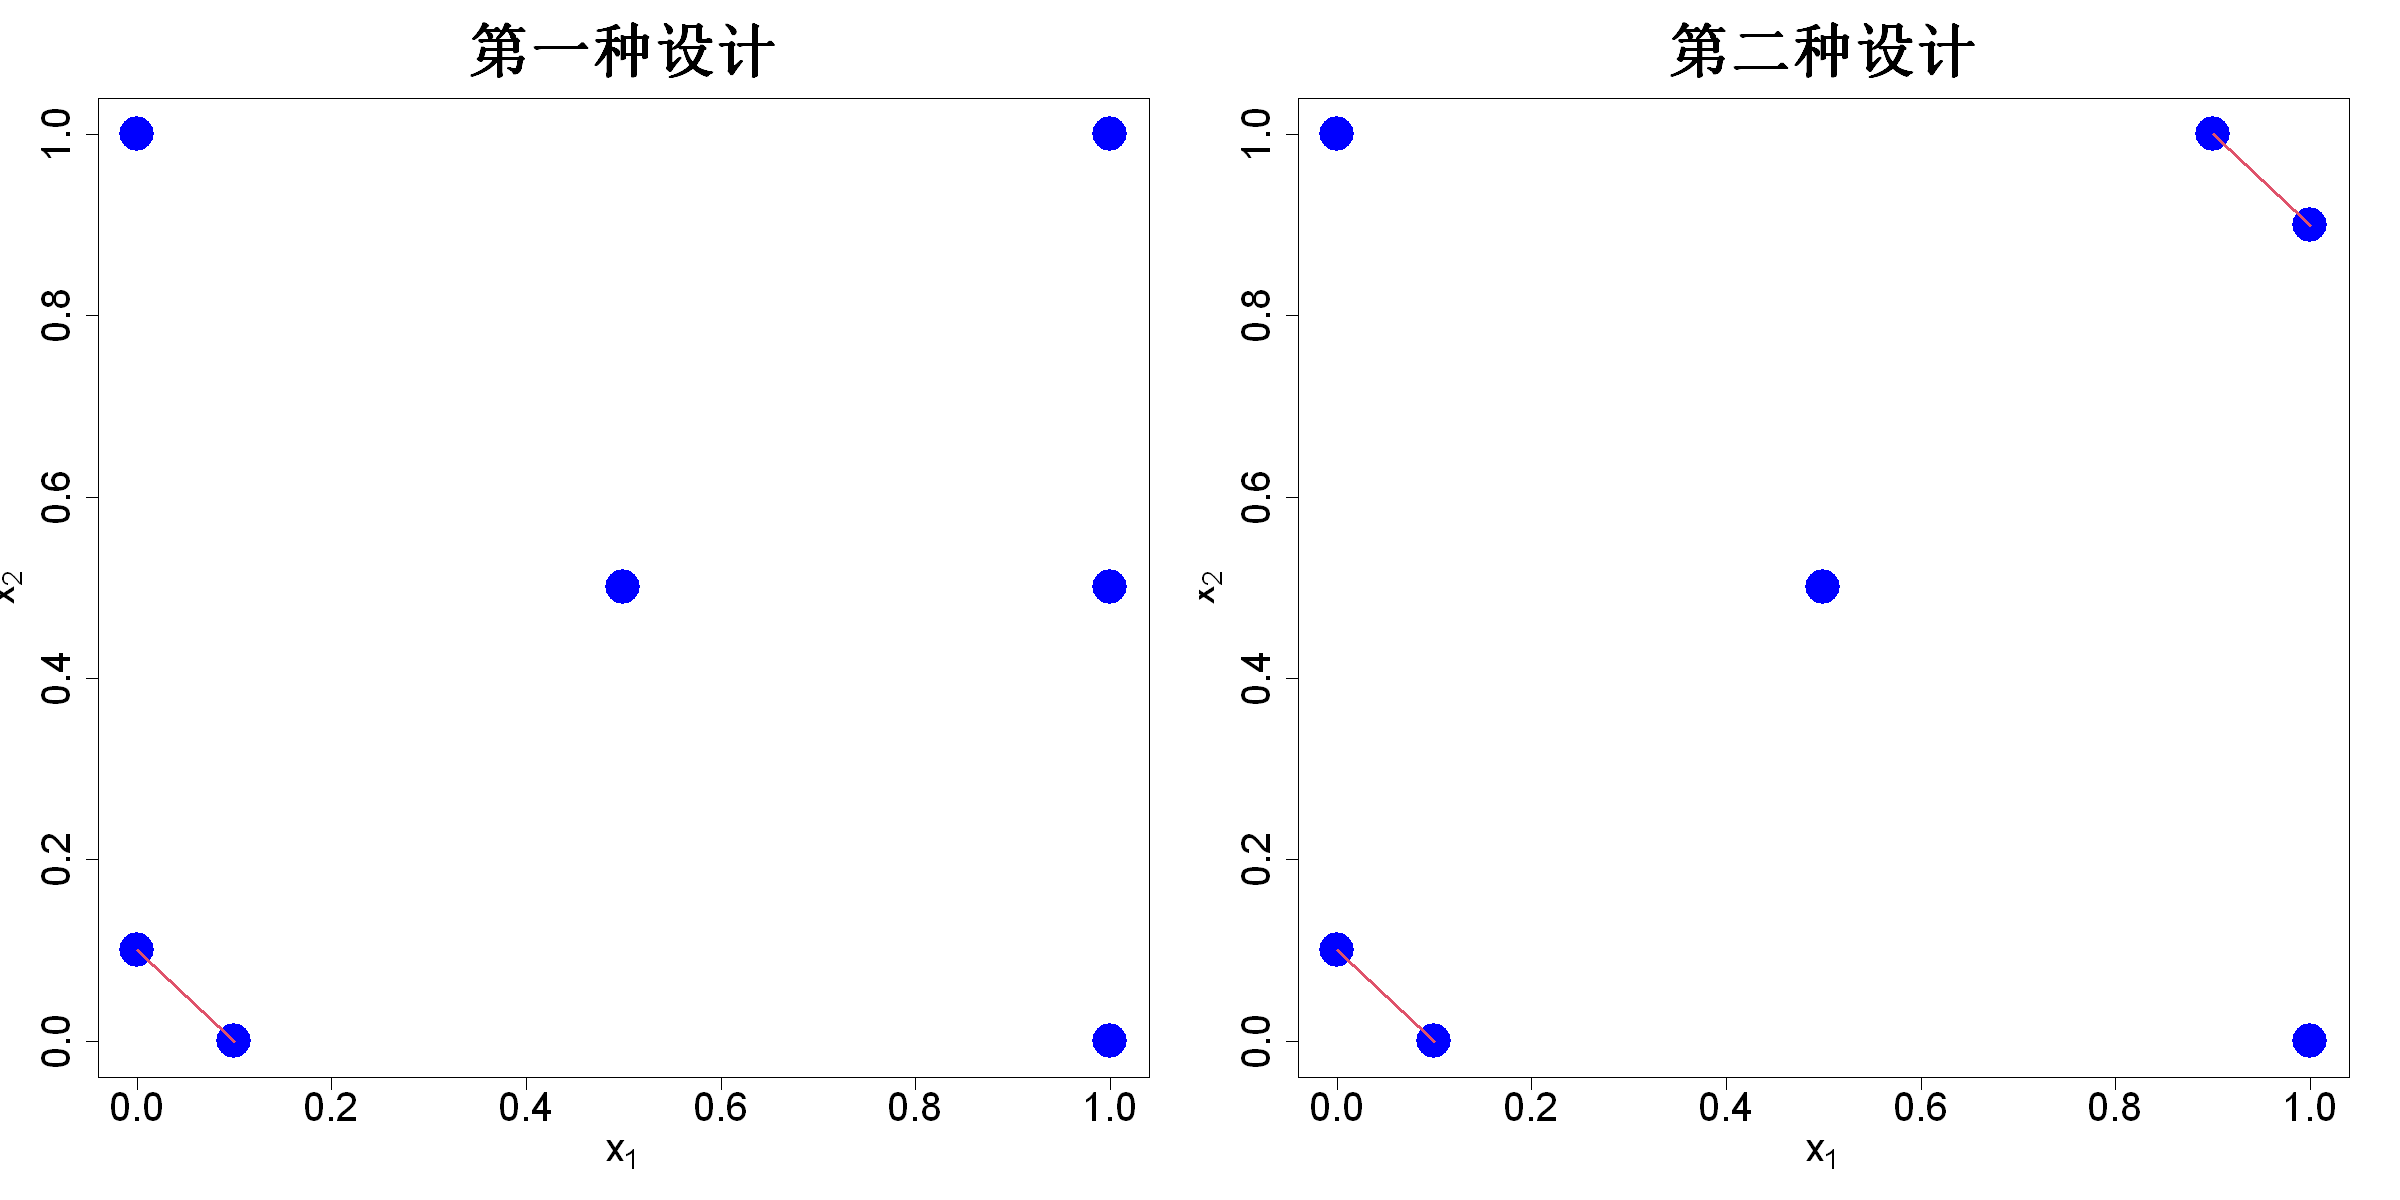

In [1]:
if(!dir.exists("data")) dir.create("data")
if(!file.exists("data/4.3-D.csv")){
  p=2;n=7
  D1=matrix(c(0,.1,.1,0,0,1,1,1,1,.5,1,0,.5,.5),nrow=n,ncol=p,byrow=TRUE)
  D2=matrix(c(0,.1,.1,0,0,1,.9,1,1,.9,1,0,.5,.5),nrow=n,ncol=p,byrow=TRUE)
  write.csv(data.frame(D1=D1,D2=D2),"data/4.3-D.csv",row.names=FALSE)
}

df_D=read.csv("data/4.3-D.csv")
D1=cbind(df_D$D1.1,df_D$D1.2)
D2=cbind(df_D$D2.1,df_D$D2.2)

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
plot(D1,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",cex=4,main="第一种设计",cex.main=3)
segments(0,.1,.1,0,col=2,lwd=3)
plot(D2,xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,pch=16,col="blue",cex=4,main="第二种设计",cex.main=3)
segments(0,.1,.1,0,col=2,lwd=3)
segments(.9,1,1,.9,col=2,lwd=3)
par(mfrow=c(1,1))

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$